<a href="https://colab.research.google.com/github/smminhaz/practice/blob/main/Day_6_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/DataSets/Agriculture/agriculture_dataset.csv')
df2 = pd.read_csv('/content/drive/MyDrive/DataSets/House Prices-Advanced Regression Techniques/House Prices-Advanced Regression Techniques-train.csv')
df3 = pd.read_csv('/content/drive/MyDrive/DataSets/Titanic - Machine Learning from Disaster/Titanic Machine Learning from Disaster-train.csv')

Mounted at /content/drive


In [4]:
df.head()

,Farm_ID,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters)
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69


In [5]:
df2.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df3.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Farm_ID                    50 non-null     object 
 1   Crop_Type                  50 non-null     object 
 2   Farm_Area(acres)           50 non-null     float64
 3   Irrigation_Type            50 non-null     object 
 4   Fertilizer_Used(tons)      50 non-null     float64
 5   Pesticide_Used(kg)         50 non-null     float64
 6   Yield(tons)                50 non-null     float64
 7   Soil_Type                  50 non-null     object 
 8   Season                     50 non-null     object 
 9   Water_Usage(cubic meters)  50 non-null     float64
dtypes: float64(5), object(5)
memory usage: 4.0+ KB


,Farm_Area(acres),Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Water_Usage(cubic meters)
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,254.963800,4.905400,2.398000,27.059200,56724.295600
std,139.417782,2.732689,1.438613,13.345789,27264.992053
min,12.500000,0.500000,0.140000,3.860000,5869.750000
25%,135.710000,2.437500,0.972500,16.190000,37818.152500
50%,281.980000,5.045000,2.330000,28.970000,54097.075000
75%,368.107500,6.885000,3.417500,37.860000,82240.032500
max,483.880000,9.960000,4.990000,48.020000,94754.730000


In [8]:
df2.info()
df2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
df3.info()
df3.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
print(df.isnull().sum().sum())

0


In [11]:
print(df2.isnull().sum().sum())

7829


In [12]:
print(df3.isnull().sum().sum())

866


In [13]:
# 1. Define your dictionary first (Example: inject 5 NaNs in ColA, 10 in ColB)
inject = {
    'Farm_Area(acres)': 5,
    'Fertilizer_Used(tons)': 10,
    'Water_Usage(cubic meters)': 15,
    'Soil_Type': 20
}

# 2. Now run your original injection code safely
np.random.seed(42)
for col, n in inject.items():
    idx = np.random.choice(df.index, size=n, replace=False)
    df.loc[idx, col] = np.nan

# 3. Verify
df.isnull().sum()[df.isnull().sum() > 0]

,0
Farm_Area(acres),5
Fertilizer_Used(tons),10
Soil_Type,20
Water_Usage(cubic meters),15


In [14]:
# Numeric → median; Categorical → mode (most frequent)
df['Farm_Area(acres)'].fillna(df['Farm_Area(acres)'].median(), inplace=True)
df['Fertilizer_Used(tons)'].fillna(df['Fertilizer_Used(tons)'].mean(), inplace=True)
df['Water_Usage(cubic meters)'].fillna(df['Water_Usage(cubic meters)'].median(), inplace=True)
df['Soil_Type'].fillna(df['Soil_Type'].mode()[0], inplace=True)

df.isnull().sum().sum()  # should be 0

np.int64(0)

In [27]:
# 1. Create a clean copy and drop the ID column
df2_enc = df2.drop(columns=['Id']).copy()

# 2. THE SHIELD: Fix the 'NA' trap first so they don't get overwritten by the mode
na_cols = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
           'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
           'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

for col in na_cols:
    if col in df2_enc.columns:
        df2_enc[col] = df2_enc[col].fillna('None')

# 3. NOW loop through the remaining columns safely
for col in df2_enc.columns:
    if df2_enc[col].isnull().sum() > 0:

        # If numeric -> fill with median
        if df2_enc[col].dtype in ['int64', 'float64']:
            df2_enc[col].fillna(df2_enc[col].median(), inplace=True)

        # If categorical -> fill with mode safely
        elif df2_enc[col].dtype == 'object':
            df2_enc[col].fillna(df2_enc[col].mode()[0], inplace=True)

# 4. Verify that ALL missing values are gone
print("Remaining missing values:", df2_enc.isnull().sum().sum())


Remaining missing values: 0


In [28]:
# 1. Loop through every column in df3
for col in df3.columns:
    # Check if the column has missing values
    if df3[col].isnull().sum() > 0:

        # If the column is numeric -> fill with median
        if df3[col].dtype in ['int64', 'float64']:
            median_value = df3[col].median()
            df3[col].fillna(median_value, inplace=True)

        # If the column is categorical (text) -> fill with mode
        elif df3[col].dtype == 'object':
            # CRITICAL FIX: Add [0] to get the actual most frequent text value
            mode_value = df3[col].mode()[0]
            df3[col].fillna(mode_value, inplace=True)

# 2. Verify that all 866 missing values are completely gone
print("Remaining missing values:", df3.isnull().sum().sum())


Remaining missing values: 0


In [17]:
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (50, 10)


In [18]:
df2.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df2.shape}")

Shape after removing duplicates: (1460, 81)


In [19]:
df3.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df3.shape}")

Shape after removing duplicates: (891, 12)


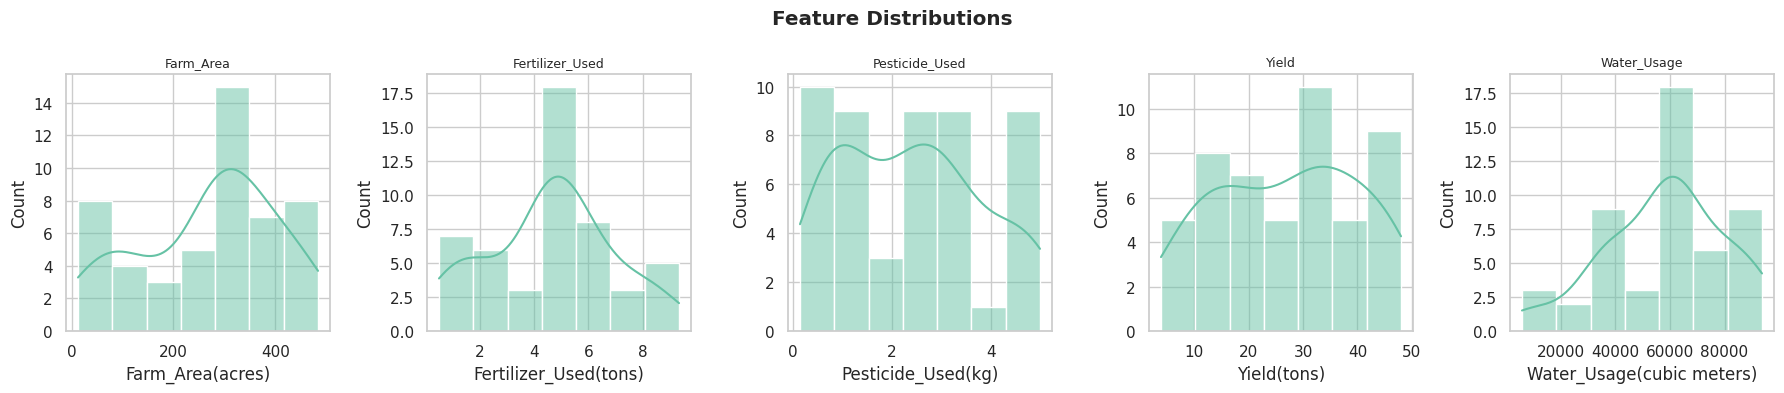

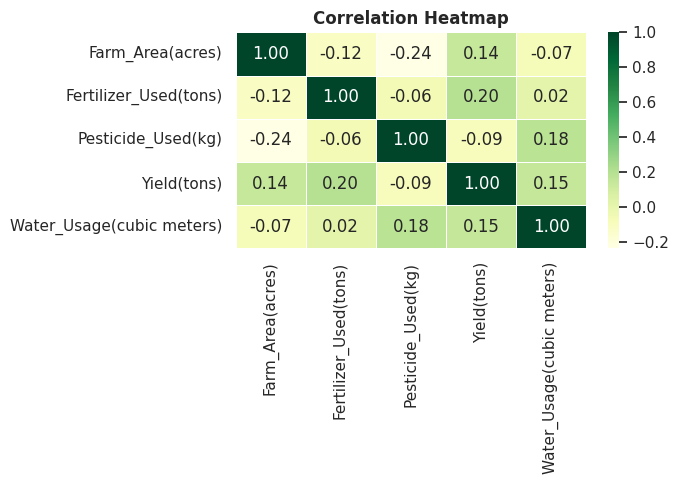

In [20]:
num_cols = ['Farm_Area(acres)', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)',
            'Yield(tons)', 'Water_Usage(cubic meters)']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col.split('(')[0], fontsize=9)
plt.suptitle('Feature Distributions', fontweight='bold'); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold'); plt.tight_layout(); plt.show()

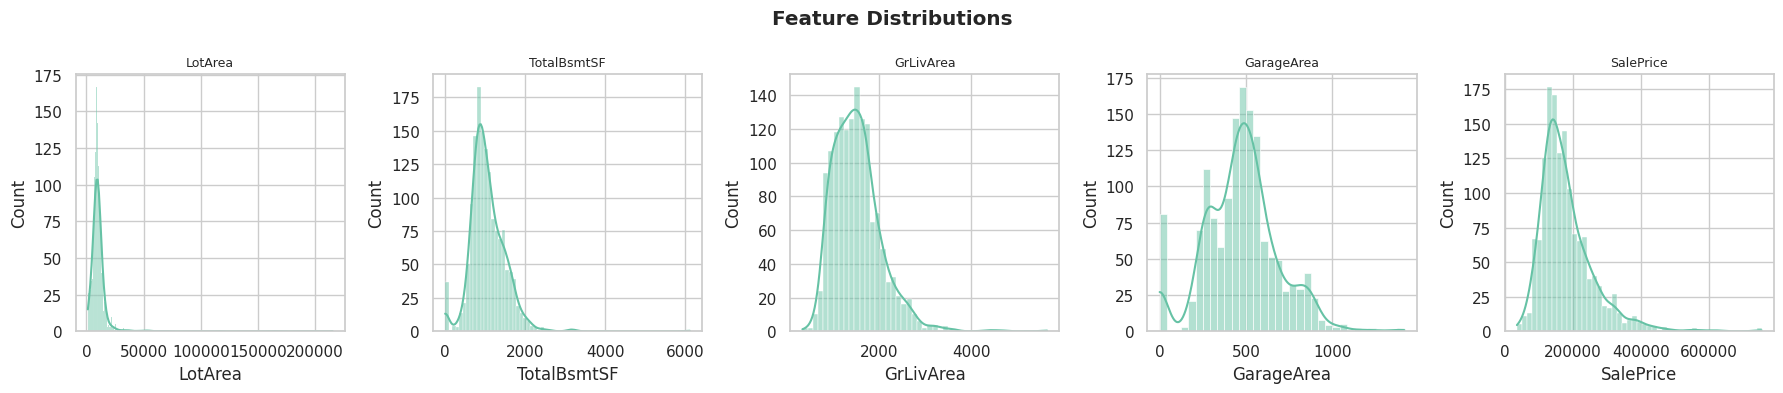

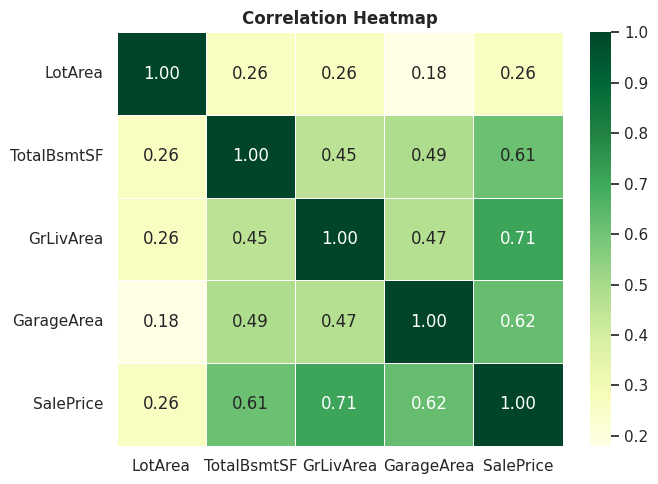

In [22]:
# 1. Define the numerical columns present in your df2 housing dataset
num_cols = ['LotArea', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'SalePrice']

# 2. Generate the 5 distribution histograms side-by-side
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df2[col], ax=ax, kde=True)
    # Cleans up the title by splitting if there are any brackets
    ax.set_title(col.split('(')[0], fontsize=9)
plt.suptitle('Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Generate the correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df2[num_cols].corr(), annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()


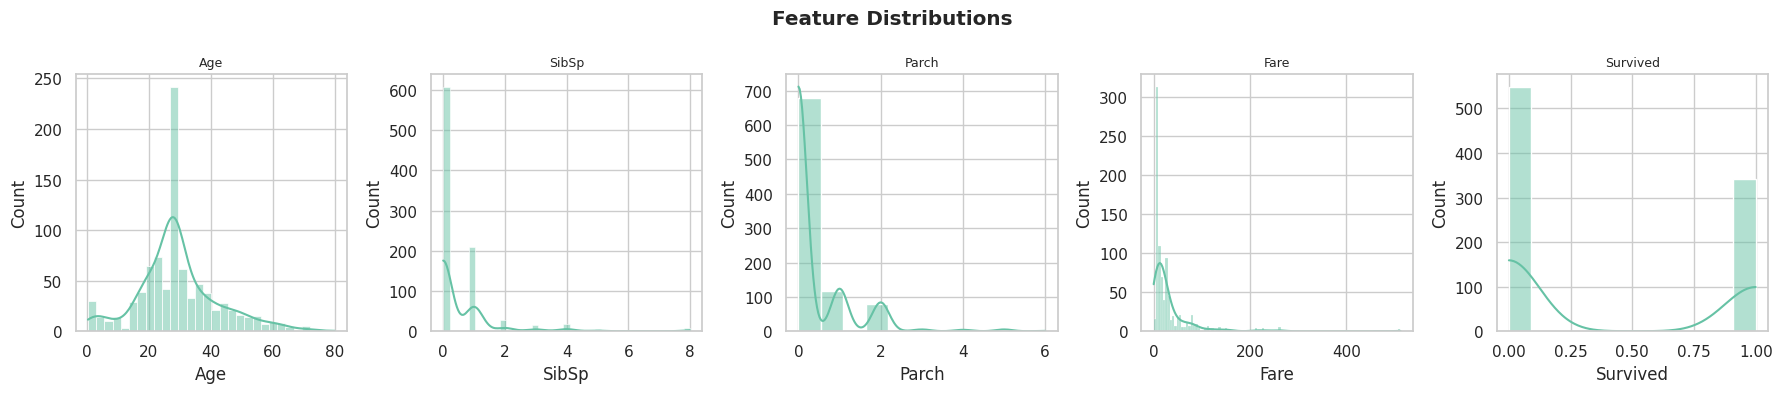

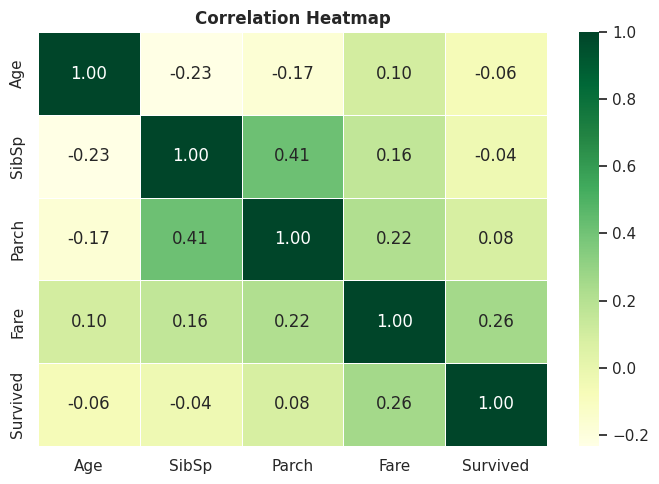

In [23]:
# 1. Define the numerical columns present in your df3 Titanic dataset
num_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'Survived']

# 2. Generate the 5 distribution histograms side-by-side
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df3[col], ax=ax, kde=True)
    # Cleans up titles if any brackets exist
    ax.set_title(col.split('(')[0], fontsize=9)
plt.suptitle('Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Generate the correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df3[num_cols].corr(), annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()


In [24]:
cat_cols = ['Crop_Type', 'Irrigation_Type', 'Soil_Type', 'Season']
df_enc = df.drop(columns=['Farm_ID']).copy()

# Label Encoding — best for tree-based models
le = LabelEncoder()
df_enc['Season_LE'] = le.fit_transform(df_enc['Season'])
df_enc.head(10)

,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters),Season_LE
0,Cotton,329.40,Sprinkler,4.59075,2.21,14.44,Loamy,Kharif,76648.20,0
1,Carrot,18.67,Manual,4.77000,4.36,42.91,Peaty,Kharif,60202.14,0
2,Sugarcane,306.03,Flood,4.59075,0.56,33.44,Silty,Kharif,75538.56,0
3,Tomato,380.21,Rain-fed,3.32000,4.35,34.08,Clay,Zaid,60202.14,2
4,Tomato,135.56,Sprinkler,8.33000,4.48,43.28,Clay,Zaid,93718.69,2
5,Sugarcane,12.50,Sprinkler,6.42000,2.25,38.18,Loamy,Zaid,60202.14,2
6,Soybean,360.06,Drip,1.83000,2.37,44.93,Sandy,Rabi,40583.57,1
7,Rice,464.60,Drip,5.18000,0.91,4.23,Clay,Kharif,9392.38,0
8,Maize,389.37,Drip,0.57000,4.93,3.86,Peaty,Rabi,60202.14,1
9,Soybean,184.37,Drip,2.18000,2.67,17.25,Clay,Kharif,60202.14,0


In [29]:
# 1. Initialize the LabelEncoder
le = LabelEncoder()

# 2. Encode the categorical columns on your ALREADY CLEANED df2_enc
df2_enc['MSZoning_LE'] = le.fit_transform(df2_enc['MSZoning'])
df2_enc['CentralAir_LE'] = le.fit_transform(df2_enc['CentralAir'])

# 3. View the changes for your real first row safely
print(df2_enc[['MSZoning', 'MSZoning_LE', 'CentralAir', 'CentralAir_LE']].iloc[0])


MSZoning         RL
MSZoning_LE       3
CentralAir        Y
CentralAir_LE     1
Name: 0, dtype: object


In [26]:
# 1. Drop the identifier column 'PassengerId'
df3_enc = df3.drop(columns=['PassengerId']).copy()

# 2. Initialize the LabelEncoder
le = LabelEncoder()

# 3. Encode the categorical columns
df3_enc['Sex_LE'] = le.fit_transform(df3_enc['Sex'])
df3_enc['Embarked_LE'] = le.fit_transform(df3_enc['Embarked'])

# 4. View the changes
print(df3_enc[['Sex', 'Sex_LE', 'Embarked', 'Embarked_LE']].head(10))


      Sex  Sex_LE Embarked  Embarked_LE
0    male       1        S            2
1  female       0        C            0
2  female       0        S            2
3  female       0        S            2
4    male       1        S            2
5    male       1        Q            1
6    male       1        S            2
7    male       1        S            2
8  female       0        S            2
9  female       0        C            0


In [30]:
# One-Hot Encoding — best for linear / neural models
df_ohe = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True)
df_ohe.head(3)

,Farm_Area(acres),Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Water_Usage(cubic meters),Season_LE,Crop_Type_Carrot,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Potato,...,Irrigation_Type_Flood,Irrigation_Type_Manual,Irrigation_Type_Rain-fed,Irrigation_Type_Sprinkler,Soil_Type_Loamy,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silty,Season_Rabi,Season_Zaid
0,329.40,4.59075,2.21,14.44,76648.20,0,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False
1,18.67,4.77000,4.36,42.91,60202.14,0,True,False,False,False,...,False,True,False,False,False,True,False,False,False,False
2,306.03,4.59075,0.56,33.44,75538.56,0,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False


In [31]:
# One-Hot Encoding — best for linear / neural models
# 1. Automatically find all categorical (text) columns in df2_enc
cat_cols_df2 = df2_enc.select_dtypes(include=['object']).columns.tolist()

# 2. Apply One-Hot Encoding and drop the first category to avoid redundancy
df2_ohe = pd.get_dummies(df2_enc, columns=cat_cols_df2, drop_first=True)

# 3. View the first 3 rows of your newly transformed numeric dataset
df2_ohe.head(3)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False


In [32]:
# One-Hot Encoding — best for linear / neural models
# 1. Define the categorical columns to encode for the Titanic dataset
cat_cols_df3 = ['Sex', 'Embarked']

# 2. Apply One-Hot Encoding and drop the first category to prevent redundancy
df3_ohe = pd.get_dummies(df3_enc, columns=cat_cols_df3, drop_first=True)

# 3. View the first 3 rows of your transformed Titanic dataset
df3_ohe.head(3)


,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_LE,Embarked_LE,Sex_male,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,B96 B98,1,2,True,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,0,0,False,False,False
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,0,2,False,False,True


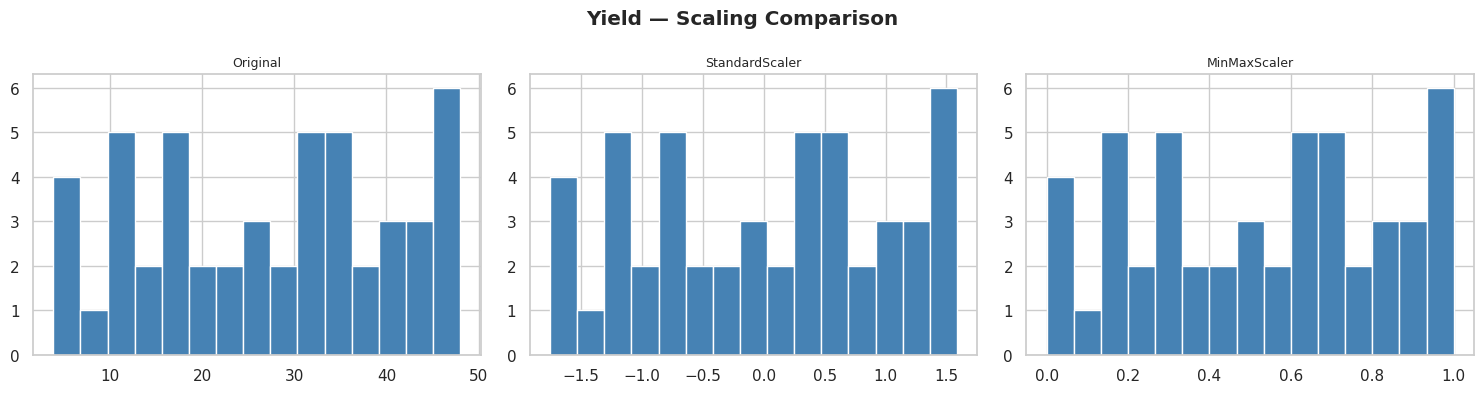

In [36]:
#Scaling & Normalization
# 1. Point back to your agricultural dataset columns
num_cols = ['Farm_Area(acres)', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)',
            'Yield(tons)', 'Water_Usage(cubic meters)']

# 2. Extract from df (NOT df2)
X_num = df[num_cols].copy()
yield_idx = num_cols.index('Yield(tons)')

# 3. Calculate scales based on 'Yield(tons)'
scalers = {
    'Original'       : X_num['Yield(tons)'],
    'StandardScaler'  : pd.Series(StandardScaler().fit_transform(X_num)[:, yield_idx]),
    'MinMaxScaler'    : pd.Series(MinMaxScaler().fit_transform(X_num)[:, yield_idx])
}

# 4. Generate the exact 3 flat, uniform plots from Image 1
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.hist(data, bins=15, color='steelblue', edgecolor='white')
    ax.set_title(name, fontsize=9)
plt.suptitle('Yield — Scaling Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

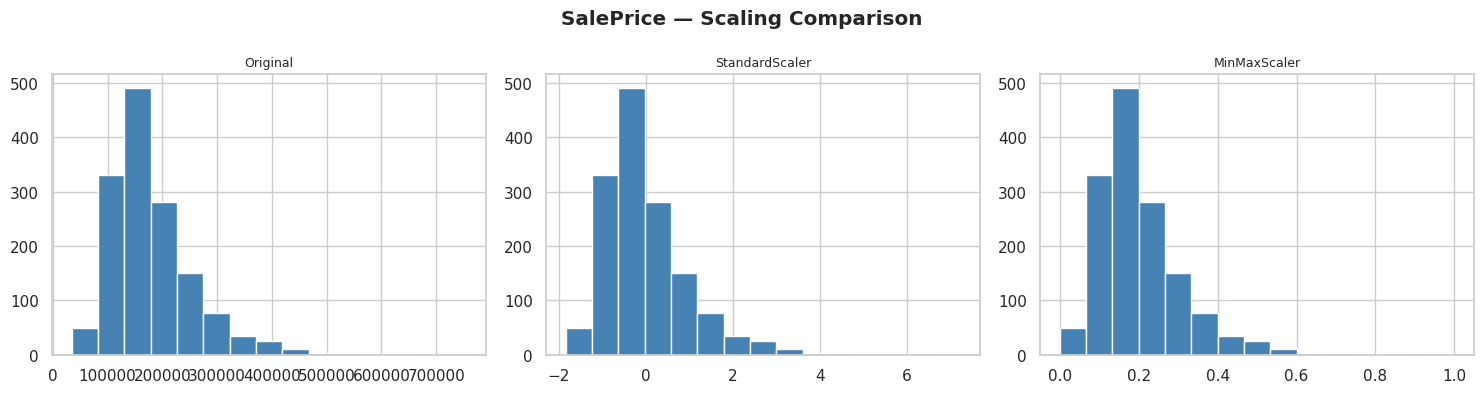

In [38]:
#Scaling & Normalization
# 1. Define the numerical columns that exist in df2
num_cols = ['LotArea', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'SalePrice']

# 2. Extract the numbers from df2 and target 'SalePrice'
X_num = df2[num_cols].copy()
target_col = 'SalePrice'
target_idx = num_cols.index(target_col)

# 3. Calculate scales based on 'SalePrice'
scalers = {
    'Original'       : X_num[target_col],
    'StandardScaler'  : pd.Series(StandardScaler().fit_transform(X_num)[:, target_idx]),
    'MinMaxScaler'    : pd.Series(MinMaxScaler().fit_transform(X_num)[:, target_idx])
}

# 4. Generate the 3-panel plot comparison for SalePrice
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.hist(data, bins=15, color='steelblue', edgecolor='white')
    ax.set_title(name, fontsize=9)
plt.suptitle('SalePrice — Scaling Comparison', fontweight='bold')
plt.tight_layout()
plt.show()


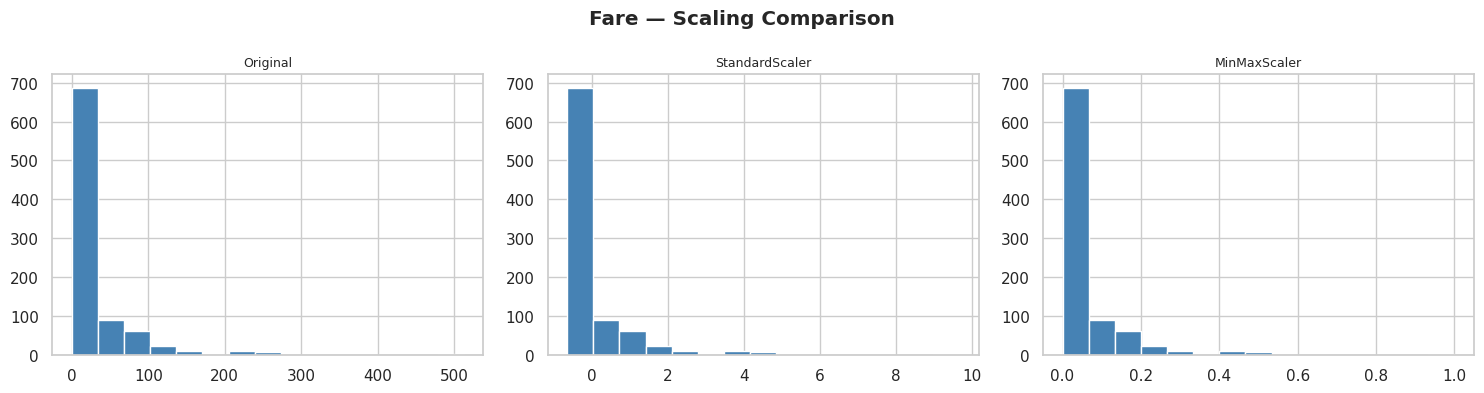

In [39]:
#Scaling & Normalization
# 1. Define the numerical columns that exist in df3
num_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'Survived']

# 2. Extract the numbers from df3 and target 'Fare'
X_num = df3[num_cols].copy()
target_col = 'Fare'
target_idx = num_cols.index(target_col)

# 3. Calculate scales based on 'Fare'
scalers = {
    'Original'       : X_num[target_col],
    'StandardScaler'  : pd.Series(StandardScaler().fit_transform(X_num)[:, target_idx]),
    'MinMaxScaler'    : pd.Series(MinMaxScaler().fit_transform(X_num)[:, target_idx])
}

# 4. Generate the 3-panel plot comparison for Fare
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.hist(data, bins=15, color='steelblue', edgecolor='white')
    ax.set_title(name, fontsize=9)
plt.suptitle('Fare — Scaling Comparison', fontweight='bold')
plt.tight_layout()
plt.show()


X_train: (40, 23)  |  X_test: (10, 23)


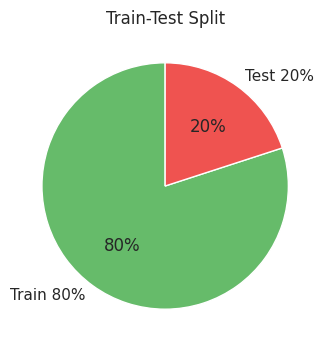

In [40]:
#Train-Test Split
X = df_ohe.drop(columns=['Yield(tons)', 'Season_LE'], errors='ignore')
y = df['Yield(tons)'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

plt.figure(figsize=(4, 4))
plt.pie([len(X_train), len(X_test)], labels=['Train 80%', 'Test 20%'],
        colors=['#66BB6A','#EF5350'], autopct='%1.0f%%', startangle=90)
plt.title('Train-Test Split'); plt.show()

df2_train: (1168, 246)  |  df2_test: (292, 246)


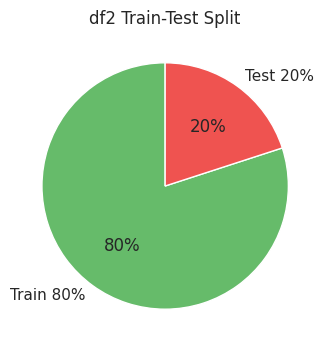

In [42]:
#Train-Test Split
# 1. Define Features (X) and Target (y)
X_df2 = df2_ohe.drop(columns=['SalePrice'], errors='ignore')
y_df2 = df2_ohe['SalePrice'].values

# 2. Perform the 80/20 split
X_train_d2, X_test_d2, y_train_d2, y_test_d2 = train_test_split(
    X_df2, y_df2, test_size=0.2, random_state=42
)

# 3. Print out the shapes of your splits
print(f'df2_train: {X_train_d2.shape}  |  df2_test: {X_test_d2.shape}')

# 4. Plot the Train-Test breakdown pie chart
plt.figure(figsize=(4, 4))
plt.pie([len(X_train_d2), len(X_test_d2)], labels=['Train 80%', 'Test 20%'],
        colors=['#66BB6A','#EF5350'], autopct='%1.0f%%', startangle=90)
plt.title('df2 Train-Test Split')
plt.show()


df3_train: (712, 11)  |  df3_test: (179, 11)


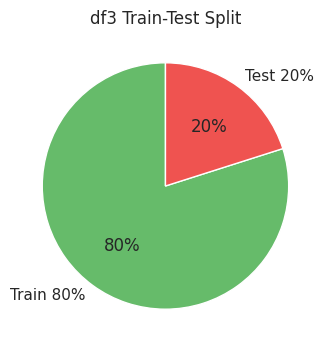

In [43]:
#Train-Test Split
# 1. Define Features (X) and Target (y), dropping the target and raw string columns
cols_to_drop = ['Survived', 'Name', 'Ticket']
X_df3 = df3_ohe.drop(columns=cols_to_drop, errors='ignore')
y_df3 = df3_ohe['Survived'].values

# 2. Perform the 80/20 split
X_train_d3, X_test_d3, y_train_d3, y_test_d3 = train_test_split(
    X_df3, y_df3, test_size=0.2, random_state=42
)

# 3. Print out the shapes of your splits
print(f'df3_train: {X_train_d3.shape}  |  df3_test: {X_test_d3.shape}')

# 4. Plot the Train-Test breakdown pie chart
plt.figure(figsize=(4, 4))
plt.pie([len(X_train_d3), len(X_test_d3)], labels=['Train 80%', 'Test 20%'],
        colors=['#66BB6A','#EF5350'], autopct='%1.0f%%', startangle=90)
plt.title('df3 Train-Test Split')
plt.show()


In [44]:
#Full PREprocessing Pipeline
data = pd.read_csv('/content/drive/MyDrive/DataSets/Agriculture/agriculture_dataset.csv')

# Inject NaNs (same seed for reproducibility)
np.random.seed(42)
for col, n in {'Farm_Area(acres)':5, 'Fertilizer_Used(tons)':4,
               'Soil_Type':3, 'Water_Usage(cubic meters)':3}.items():
    data.loc[np.random.choice(data.index, n, replace=False), col] = np.nan

# Fill missing
data['Farm_Area(acres)'].fillna(data['Farm_Area(acres)'].median(), inplace=True)
data['Fertilizer_Used(tons)'].fillna(data['Fertilizer_Used(tons)'].mean(), inplace=True)
data['Water_Usage(cubic meters)'].fillna(data['Water_Usage(cubic meters)'].median(), inplace=True)
data['Soil_Type'].fillna(data['Soil_Type'].mode()[0], inplace=True)

# Clean
data.drop_duplicates(inplace=True)
data.drop(columns=['Farm_ID'], inplace=True)
for col in data.select_dtypes(include=np.number).columns:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    data = data[data[col].between(q1 - 1.5*iqr, q3 + 1.5*iqr)]

# Encode → Split → Scale
data = pd.get_dummies(data, columns=['Crop_Type','Irrigation_Type','Soil_Type','Season'], drop_first=True)
X = data.drop(columns=['Yield(tons)']).values
y = data['Yield(tons)'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Pipeline complete → X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Pipeline complete → X_train: (40, 23)  |  X_test: (10, 23)


In [45]:
#Full PREprocessing Pipeline
# 1. Load the original dataset into data2
data2 = pd.read_csv('/content/drive/MyDrive/DataSets/House Prices-Advanced Regression Techniques/House Prices-Advanced Regression Techniques-train.csv')

# 2. Drop the identifier column 'Id' right away
data2.drop(columns=['Id'], inplace=True, errors='ignore')

# 3. FIX THE 'NA' TRAP: Replace structural missing categorical values with string 'None'
na_cols = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
           'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
           'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

for col in na_cols:
    if col in data2.columns:
        data2[col] = data2[col].fillna('None')

# 4. Handle remaining true missing values (Median for Numeric, Mode for Categorical)
for col in data2.columns:
    if data2[col].isnull().sum() > 0:
        if data2[col].dtype in ['int64', 'float64']:
            data2[col].fillna(data2[col].median(), inplace=True)
        elif data2[col].dtype == 'object':
            data2[col].fillna(data2[col].mode()[0], inplace=True)

# 5. Clean Duplicates
data2.drop_duplicates(inplace=True)

# 6. Remove Statistical Outliers using IQR method on numeric columns
# (Skips your target 'SalePrice' so you don't lose valid luxury property prices)
for col in data2.select_dtypes(include=np.number).columns:
    if col != 'SalePrice':
        q1, q3 = data2[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        data2 = data2[data2[col].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)]

# 7. One-Hot Encode all remaining categorical text columns
cat_cols_data2 = data2.select_dtypes(include=['object']).columns.tolist()
data2_encoded = pd.get_dummies(data2, columns=cat_cols_data2, drop_first=True)

# 8. Split into Features (X) and Target (y)
X = data2_encoded.drop(columns=['SalePrice']).values
y = data2_encoded['SalePrice'].values

# 9. Perform 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 10. Scale features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Pipeline complete → X_train: {X_train.shape}  |  X_test: {X_test.shape}')


Pipeline complete → X_train: (447, 190)  |  X_test: (112, 190)


In [46]:
#Full PREprocessing Pipeline
# 1. Load the original dataset from your designated folder path into data3
data3 = pd.read_csv('/content/drive/MyDrive/DataSets/Titanic - Machine Learning from Disaster/Titanic Machine Learning from Disaster-train.csv')

# 2. Drop unique row identifier and text strings that do not add predictive weight
# (Cabin has roughly 80% missing data, so we drop it here to prevent poor imputation)
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
data3.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 3. Handle remaining missing values (Median for Numeric like Age; Mode for Categorical like Embarked)
for col in data3.columns:
    if data3[col].isnull().sum() > 0:
        if data3[col].dtype in ['int64', 'float64']:
            data3[col].fillna(data3[col].median(), inplace=True)
        elif data3[col].dtype == 'object':
            # Safely extract the first element from the mode Series
            data3[col].fillna(data3[col].mode()[0], inplace=True)

# 4. Clean duplicates
data3.drop_duplicates(inplace=True)

# 5. Remove Statistical Outliers using IQR method on continuous numeric features
# (We explicitly skip your binary columns 'Survived' and 'Pclass' so we do not wipe out valid label structures)
continuous_cols = ['Age', 'SibSp', 'Parch', 'Fare']
for col in continuous_cols:
    if col in data3.columns:
        q1, q3 = data3[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        data3 = data3[data3[col].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)]

# 6. One-Hot Encode all remaining non-numeric categorical columns ('Sex', 'Embarked')
cat_cols_data3 = data3.select_dtypes(include=['object']).columns.tolist()
data3_encoded = pd.get_dummies(data3, columns=cat_cols_data3, drop_first=True)

# 7. Isolate independent features (X) and target variable (y)
X = data3_encoded.drop(columns=['Survived']).values
y = data3_encoded['Survived'].values

# 8. Perform 80% Train / 20% Test partition
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 9. Apply StandardScaler to map distributions to a mean of 0 and variance of 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Pipeline complete → X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Pipeline complete → X_train: (375, 8)  |  X_test: (94, 8)
